# 2. the model code: hybrid convnext + vision transformer

**what this notebook shows:** the real model code, its size, one forward pass, the training settings, and the training history of the improved recipe.

idea in one line: two networks look at the same picture. convnext is good at *texture*, the vision transformer is good at *shape*. a small attention layer decides how much to trust each one for every image.

In [1]:
# find the project folder, so the notebook works from any place
import os, sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
root = Path.cwd()
while not (root / "pyproject.toml").exists():
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(root / "src"))
print("project folder:", root)

project folder: C:\Users\91738\edge-waste


In [2]:
# the attention layer and the full model, exactly as in the project
import inspect
from edgewaste.classification import hybrid_model as hm
print(inspect.getsource(hm.AttentionFusion))
print(inspect.getsource(hm.HybridConvNeXtViT.forward))

class AttentionFusion(nn.Module):
    """Learns scalar attention weights over N projected backbone features.

    Each backbone feature (already projected to `dim`) gets a learned attention
    score; scores are softmax-normalized across backbones and used to weight the
    features before concatenation. This is the "attention layer combining both"
    called for in docs/planning/stage_1 Module 3.
    """

    def __init__(self, dim: int, num_streams: int = 2):
        super().__init__()
        self.num_streams = num_streams
        self.score = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.GELU(),
            nn.Linear(dim // 2, 1),
        )

    def forward(self, feats: list[torch.Tensor]) -> torch.Tensor:
        # feats: list of [b, dim]; stack to [b, n, dim]
        stacked = torch.stack(feats, dim=1)
        scores = self.score(stacked)  # [b, n, 1]
        weights = torch.softmax(scores, dim=1)  # attention over streams
        weighted = stacked * weight

In [3]:
# build the model (no download needed: weights come from our own checkpoint later)
import torch
model = hm.HybridConvNeXtViT(pretrained=False)

def n_params(m):
    return sum(p.numel() for p in m.parameters()) / 1e6

parts = {"convnext backbone": model.convnext, "vit backbone": model.vit, "two projections": torch.nn.ModuleList([model.proj_cnx, model.proj_vit]),
         "attention fusion": model.fusion, "classifier head": model.head}
for name, part in parts.items():
    print(f"{name:20s} {n_params(part):6.2f} million parameters")
print(f"{'total':20s} {n_params(model):6.2f} million parameters")

convnext backbone     27.82 million parameters
vit backbone          21.67 million parameters
two projections        0.59 million parameters
attention fusion       0.13 million parameters
classifier head        0.54 million parameters
total                 50.75 million parameters


In [4]:
# one forward pass with a random batch, to check the shapes
x = torch.randn(2, 3, 224, 224)
model.eval()
with torch.no_grad():
    logits, attn = model(x, return_attn=True)
print("logits shape   :", tuple(logits.shape), " (2 images, 33 classes)")
print("attention shape:", tuple(attn.shape), " (2 images, 2 backbones)")
print("attention adds up to one:", attn.sum(dim=1))

logits shape   : (2, 33)  (2 images, 33 classes)
attention shape: (2, 2)  (2 images, 2 backbones)
attention adds up to one: tensor([1., 1.])


## the trained model on a real image

we load the trained checkpoint and classify one real test image. the attention numbers show how much the model used each backbone.

device: cuda | classes: 33


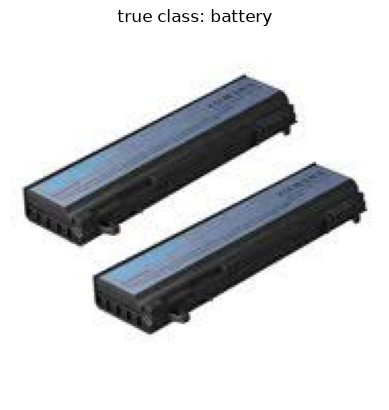

  battery                       83.6%
  plastic_trash_bags             0.8%
  cardboard_packaging            0.7%
attention  convnext: 0.86   vit: 0.14


In [5]:
# load the trained checkpoint
from edgewaste.config import Config
from edgewaste.classification.run_inference import load_for_inference
from edgewaste.common_utils import pick_device
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

cfg = Config.load("configs/classifier_convnext_vit.yaml")
cfg.model.pretrained = False
dev = pick_device()
model, names, tfm = load_for_inference("runs/stage1/best.pt", cfg, dev)
print("device:", dev, "| classes:", len(names))

cache = np.load("runs/analysis/convnext_vit/cache_test.npz", allow_pickle=True)
path = [p for p, l in zip(cache["paths"], cache["labels"]) if names[int(l)] == "battery"][3]
img = Image.open(path).convert("RGB")
x = tfm(img).unsqueeze(0).to(dev)
with torch.no_grad():
    logits, attn = model(x, return_attn=True)
probs = torch.softmax(logits, 1)[0].cpu().numpy()
top = probs.argsort()[::-1][:3]
plt.imshow(img); plt.axis("off")
plt.title("true class: battery")
plt.show()
for i in top:
    print(f"  {names[i]:28s} {probs[i] * 100:5.1f}%")
print("attention  convnext: %.2f   vit: %.2f" % tuple(attn[0].cpu().numpy()))

## training settings

these are the settings of the improved recipe (`configs/classifier_convnext_vit.yaml`). key ideas:

- **adamw** optimiser with a one-cycle learning rate
- **label smoothing 0.1** so the model is not over-confident
- **frozen backbones for 2 epochs** so the new layers learn first (this protects the pretrained features)
- **backbones learn 10 times slower** than the new layers
- **one** class-imbalance correction (a balanced sampler)

In [6]:
# print the training part of the config file
import yaml
raw = yaml.safe_load(open("configs/classifier_convnext_vit.yaml"))
for k, v in raw["train"].items():
    print(f"{k:24s} {v}")

epochs                   25
batch_size               32
lr                       0.0003
weight_decay             0.05
warmup_epochs            1
label_smoothing          0.1
num_workers              4
amp                      True
imbalance_strategy       sampler
grad_clip                1.0
backbone_lr_mult         0.1
freeze_backbone_epochs   2
output_dir               runs/stage1_v2
early_stop_patience      5


In [7]:
# the training function (the real code that was run on colab)
from edgewaste.classification import train_classifier as tc
print(inspect.getsource(tc.train))

def train(cfg: Config, smoke: bool = False) -> Path:
    seed_everything(cfg.data.seed)
    device = pick_device()
    out_dir = Path(cfg.train.output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    print(f"Device: {device}")

    train_loader, val_loader, base_train = _make_loaders(cfg, smoke)
    present = sorted(base_train.label_counts().keys())
    print(f"Classes present in train: {len(present)}/{NUM_CLASSES}")

    model = build_model(cfg.model, num_classes=NUM_CLASSES).to(device)
    print(f"Trainable parameters: {count_parameters(model):,}")

    if cfg.train.imbalance_strategy not in ("sampler", "loss_weights", "both", "none"):
        raise ValueError(f"unknown train.imbalance_strategy {cfg.train.imbalance_strategy!r}")
    class_weights = None
    if cfg.train.imbalance_strategy in ("loss_weights", "both") and not smoke:
        class_weights = base_train.class_weights().to(device)
    criterion = nn.CrossEntropyLoss(
        weight=class_weights, label_smoothing=cf

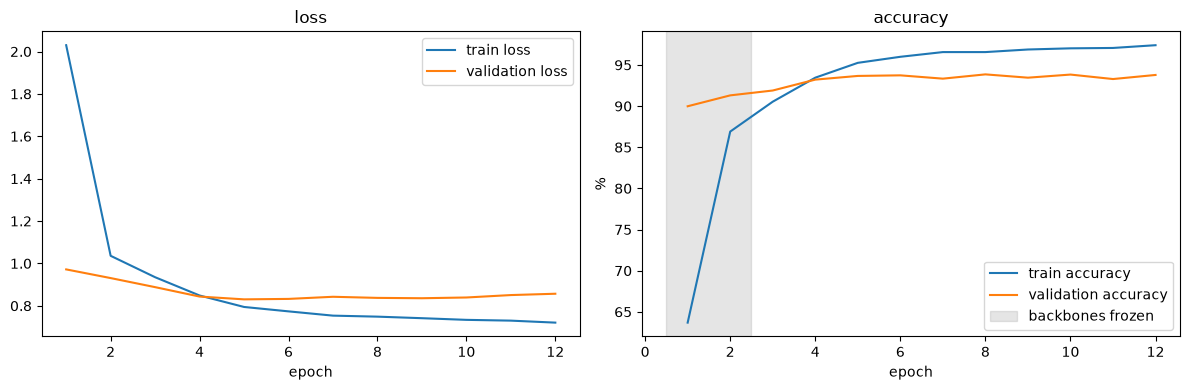

best validation accuracy 93.86% at epoch 8 of 12


In [8]:
# training history of the improved recipe (read from the saved log of the colab run)
import json
hist = json.load(open("runs/stage1_v2/history.json"))
ep = [h["epoch"] for h in hist]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ep, [h["train_loss"] for h in hist], label="train loss")
ax[0].plot(ep, [h["val_loss"] for h in hist], label="validation loss")
ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].set_title("loss")
ax[1].plot(ep, [h["train_acc"] * 100 for h in hist], label="train accuracy")
ax[1].plot(ep, [h["val_acc"] * 100 for h in hist], label="validation accuracy")
ax[1].axvspan(0.5, 2.5, color="grey", alpha=0.2, label="backbones frozen")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("%"); ax[1].legend(); ax[1].set_title("accuracy")
plt.tight_layout(); plt.show()
best = max(hist, key=lambda h: h["val_acc"])
print(f"best validation accuracy {best['val_acc'] * 100:.2f}% at epoch {best['epoch']} of {len(hist)}")